# SolarShield — Notebook 03: XGBoost Multi-output Regressor Training
**Task**: Predict `efficiency_score` (0–100) and `maintenance_days` (0–365)  
**Output**: `ml_models/xgb_regressor.pkl`

In [8]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

os.makedirs('ml_models', exist_ok=True)
RANDOM_STATE = 42

FEATURE_ORDER = [
    'voltage_mean', 'voltage_std',
    'current_mean', 'current_std',
    'power_mean',   'power_std',
    'lux_mean',
    'temperature_mean', 'humidity_mean',
    'power_rate_of_change', 'voltage_rate_of_change',
    'efficiency_ratio'
]
print('Libraries loaded.')

Libraries loaded.


## 1. Load data

In [9]:
df = pd.read_csv('data/solar_features.csv')
print(f'Dataset shape: {df.shape}')

missing = [f for f in FEATURE_ORDER if f not in df.columns]
if missing:
    raise ValueError(f'Missing features: {missing}. Run 01_data_prep.ipynb first.')

X = df[FEATURE_ORDER]
y = df[['efficiency_score', 'maintenance_days']].copy()

# Clamp targets to valid ranges
y['efficiency_score']  = y['efficiency_score'].clip(0, 100)
y['maintenance_days']  = y['maintenance_days'].clip(0, 365)

print('Target stats:')
print(y.describe())

Dataset shape: (2304, 15)
Target stats:
       efficiency_score  maintenance_days
count       2304.000000       2304.000000
mean          31.518186         82.500000
std           38.219595          4.610773
min            0.000000         75.000000
25%            0.000000         78.750000
50%            0.000000         82.500000
75%           69.420000         86.250000
max          100.000000         90.000000


## 2. Train / test split (80/20)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)
print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')

Train size: 1843 | Test size: 461


## 3. Train MultiOutputRegressor(XGBRegressor)

In [11]:
base_xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

xgb_model = MultiOutputRegressor(base_xgb)
xgb_model.fit(X_train, y_train)
print('Training complete.')

Training complete.


## 4. Evaluate

In [12]:
y_pred_raw = xgb_model.predict(X_test)  # shape (n, 2)

# Post-process: clip to valid ranges (mirrors predict() in ml_router.py)
efficiency_pred = np.clip(y_pred_raw[:, 0], 0, 100)
maintenance_pred = np.clip(np.round(y_pred_raw[:, 1]), 0, 365)

# ── efficiency_score metrics ─────────────────────────────────────────────────
eff_mae  = mean_absolute_error(y_test['efficiency_score'], efficiency_pred)
eff_rmse = np.sqrt(mean_squared_error(y_test['efficiency_score'], efficiency_pred))

# ── maintenance_days metrics ─────────────────────────────────────────────────
mnt_mae  = mean_absolute_error(y_test['maintenance_days'], maintenance_pred)
mnt_rmse = np.sqrt(mean_squared_error(y_test['maintenance_days'], maintenance_pred))

print('=== Regression Evaluation ===')
print(f'efficiency_score  → MAE: {eff_mae:.3f}  | RMSE: {eff_rmse:.3f}')
print(f'maintenance_days  → MAE: {mnt_mae:.3f}  | RMSE: {mnt_rmse:.3f}')

=== Regression Evaluation ===
efficiency_score  → MAE: 0.323  | RMSE: 0.647
maintenance_days  → MAE: 4.215  | RMSE: 4.893


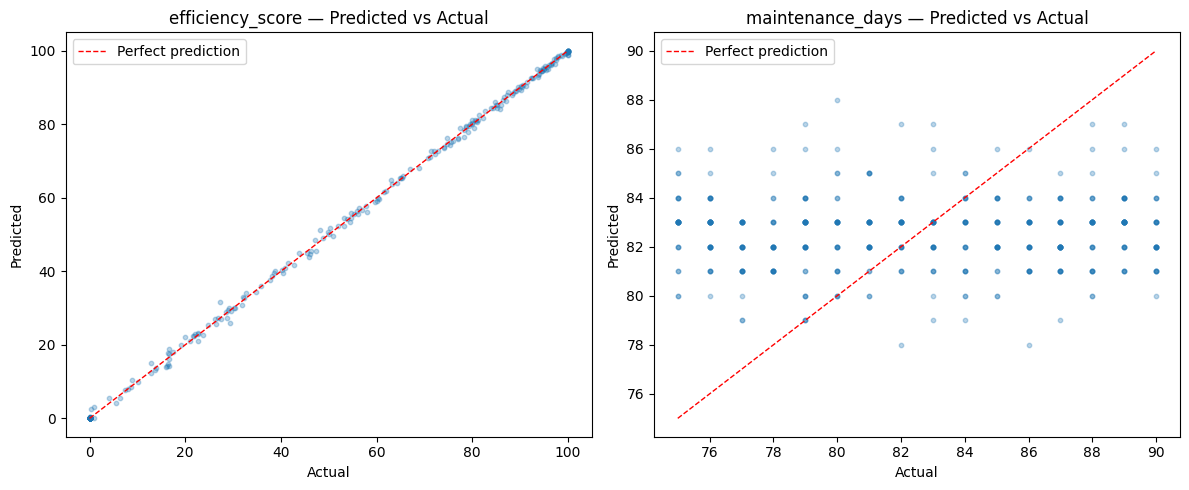

Plot saved → ml_models/xgb_regression_scatter.png


In [13]:
# Scatter plots: predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, actual, predicted, title in [
    (axes[0], y_test['efficiency_score'].values, efficiency_pred, 'efficiency_score'),
    (axes[1], y_test['maintenance_days'].values,  maintenance_pred, 'maintenance_days')
]:
    ax.scatter(actual, predicted, alpha=0.3, s=10)
    lim = [min(actual.min(), predicted.min()), max(actual.max(), predicted.max())]
    ax.plot(lim, lim, 'r--', lw=1, label='Perfect prediction')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(f'{title} — Predicted vs Actual')
    ax.legend()

plt.tight_layout()
plt.savefig('ml_models/xgb_regression_scatter.png', dpi=150)
plt.show()
print('Plot saved → ml_models/xgb_regression_scatter.png')

## 5. Save model and verify
> **Critical**: index 0 = efficiency_score, index 1 = maintenance_days

In [14]:
pkl_path = 'ml_models/xgb_regressor.pkl'
joblib.dump(xgb_model, pkl_path)
print(f'Saved → {pkl_path}')

# ── Verify load + predict ─────────────────────────────────────────────────────
loaded_model = joblib.load(pkl_path)
sample = X_test.iloc[:3]
out = loaded_model.predict(sample)  # shape (3, 2)

assert out.shape[1] == 2, 'Output should have 2 columns (efficiency, days)'
eff_check  = np.clip(out[:, 0], 0, 100)
days_check = np.clip(np.round(out[:, 1]), 0, 365)

print(f'Verification outputs:')
for i, (e, d) in enumerate(zip(eff_check, days_check)):
    print(f'  Sample {i}: efficiency_score={e:.1f}, maintenance_days={int(d)}')

print('xgb_regressor.pkl saved and verified successfully. ✓')

Saved → ml_models/xgb_regressor.pkl
Verification outputs:
  Sample 0: efficiency_score=0.0, maintenance_days=83
  Sample 1: efficiency_score=21.1, maintenance_days=82
  Sample 2: efficiency_score=0.0, maintenance_days=83
xgb_regressor.pkl saved and verified successfully. ✓
